Notes: L2 to comet in trade study, not JWST due to time intercepts, might only be 10% off

## Target Comet Range Study

In [2]:
import matplotlib.pyplot as plt
import get_comets as gc
import pandas as pd
from astropy.time import Time

def custom_filter_comets(df: pd.DataFrame, start, end) -> pd.DataFrame:
    # Filter to 0.9-1.2 AU
    df = df[df["q"] > 0.9]
    df = df[df["q"] < 1.2]

    # Filter to >0.95 ecc
    df = df[df["e"] > 0.95]

    # Filter to exact julian day range
    df = df[df["tp"] > start]
    df = df[df["tp"] < end]

    return df

In [ ]:
df = gc.get_comets()

# dates = [
#     ("1970-01-01", "1975-01-01"),
#     ("1975-01-01", "1980-01-01"),
#     ("1980-01-01", "1985-01-01"),
#     ("1985-01-01", "1990-01-01"),
#     ("1990-01-01", "1995-01-01"),
#     ("1995-01-01", "2000-01-01"),
#     ("2000-01-01", "2005-01-01"),
#     ("2005-01-01", "2010-01-01"),
#     ("2010-01-01", "2015-01-01"),
#     ("2015-01-01", "2020-01-01"),
#     ("2020-01-01", "2025-01-01"),
# ]
dates = [
    ("1983-01-01", "1986-01-01"),
    ("1986-01-01", "1989-01-01"),
    ("1989-01-01", "1992-01-01"),
    ("1992-01-01", "1995-01-01"),
    ("1995-01-01", "1998-01-01"),
    ("1998-01-01", "2001-01-01"),
    ("2001-01-01", "2004-01-01"),
    ("2004-01-01", "2007-01-01"),
    ("2007-01-01", "2010-01-01"),
    ("2010-01-01", "2013-01-01"),
    ("2013-01-01", "2016-01-01"),
    ("2016-01-01", "2019-01-01"),
    ("2019-01-01", "2022-01-01"),
    ("2022-01-01", "2025-01-01"),
]

for date in dates:
    df_filt = custom_filter_comets(df, Time(date[0]).jd, Time(date[1]).jd)
    print(f"{len(df_filt)} comets meet criteria from {date[0]} to {date[1]}")

# print(f"Got {len(df)} comets")

2 comets meet criteria from 1983-01-01 to 1986-01-01
6 comets meet criteria from 1986-01-01 to 1989-01-01
4 comets meet criteria from 1989-01-01 to 1992-01-01
4 comets meet criteria from 1992-01-01 to 1995-01-01
2 comets meet criteria from 1995-01-01 to 1998-01-01
4 comets meet criteria from 1998-01-01 to 2001-01-01
1 comets meet criteria from 2001-01-01 to 2004-01-01
6 comets meet criteria from 2004-01-01 to 2007-01-01
6 comets meet criteria from 2007-01-01 to 2010-01-01
4 comets meet criteria from 2010-01-01 to 2013-01-01
4 comets meet criteria from 2013-01-01 to 2016-01-01
5 comets meet criteria from 2016-01-01 to 2019-01-01
6 comets meet criteria from 2019-01-01 to 2022-01-01
8 comets meet criteria from 2022-01-01 to 2025-01-01


First pass: perihelion, eccentricity, and date range

In [ ]:
df = gc.get_comets()
df_filt1 = custom_filter_comets(df, Time("1970-01-01").jd, Time("2025-01-01").jd)
df_filt1 = df_filt1[df_filt1['e'] != 1.0]  # drop perfectly parabolic comets (need to be handled as special case)
df_filt1.to_csv("comets_filt1.csv", index=False)

Third pass: numbers and plots

Discovered after perihelion. margin: -223.59180064573226
Discovered after perihelion. margin: -192.00576930639875
Discovered after perihelion. margin: -149.05536988560544
Discovered after perihelion. margin: -261.60405898313843
Discovered in time. margin: 5.246484841652801
Discovered after perihelion. margin: -293.867132816285
Discovered after perihelion. margin: -398.8802121808762
Discovered in time. margin: 93.66374855719488
Discovered after perihelion. margin: -303.16110574230646
Discovered after perihelion. margin: -152.84388799511953
Discovered after perihelion. margin: -231.19232704501246
Discovered after perihelion. margin: -182.974549966996
Discovered in time. margin: 211.48075782452625
Discovered in time. margin: 851.5212771478626
Discovered in time. margin: 243.10269640468414
Discovered after perihelion. margin: -147.06459236430533
Discovered after perihelion. margin: -2.845757617370623
Discovered after perihelion. margin: -184.9650632911315
Discovered in time. margin: 151.00

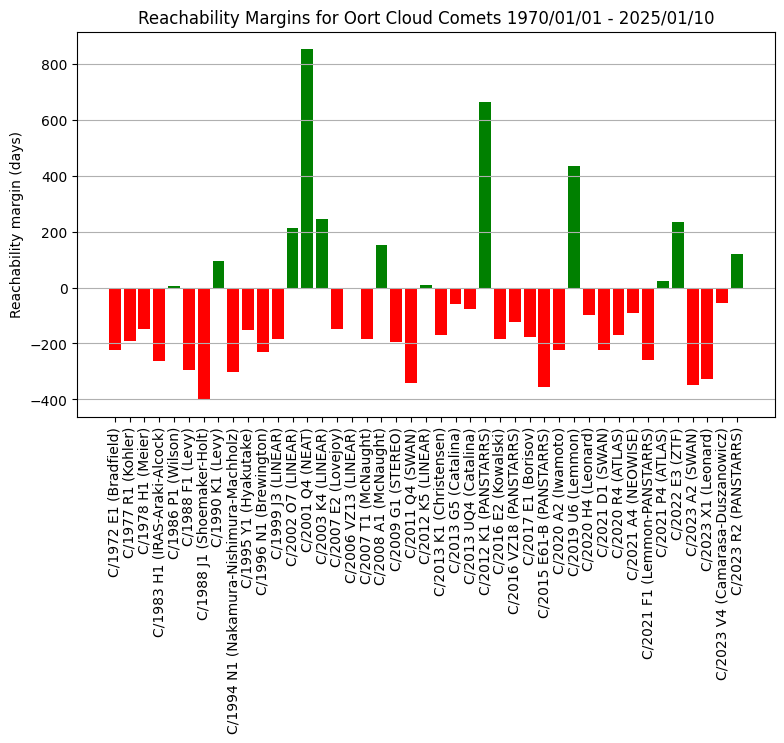

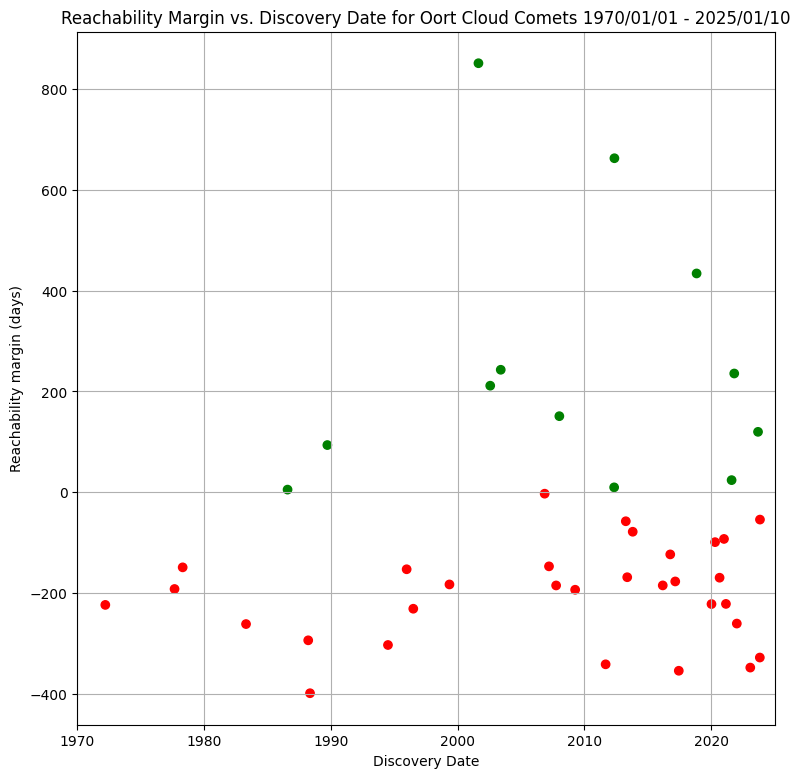

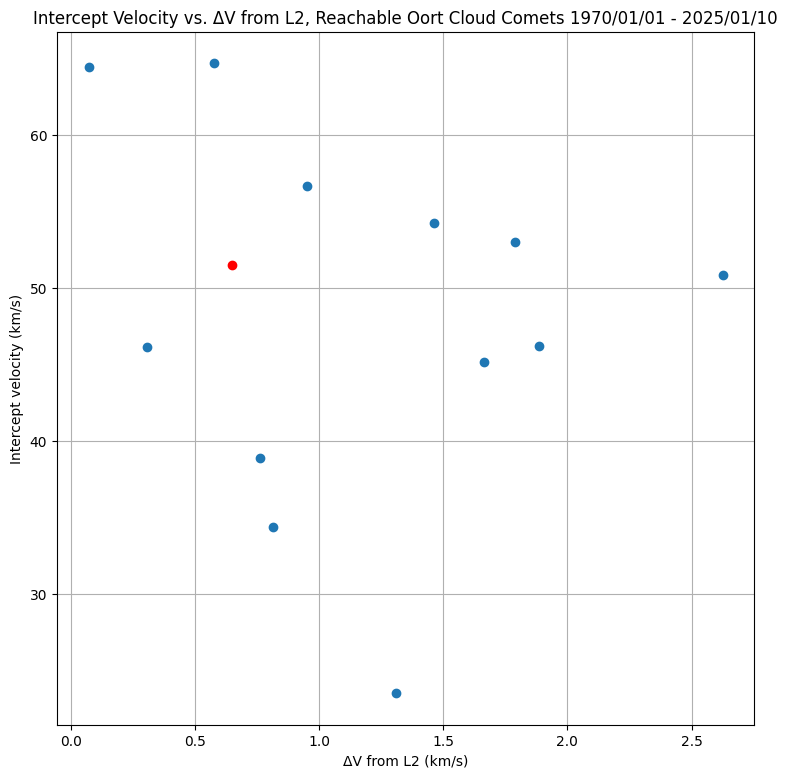

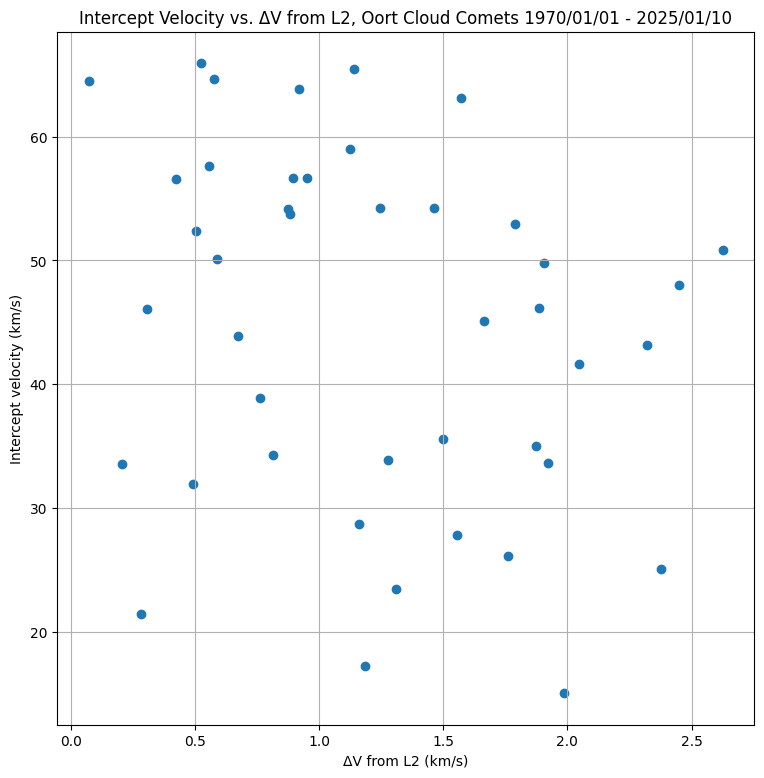

In [38]:
from datetime import datetime, timedelta
# Convert Julian day to datetime
def julian_to_datetime(julian_day):
    # Convert Julian day to datetime
    # This assumes Julian day is days since some reference date
    # Adjust the reference date according to your data
    reference_date = datetime(2023, 1, 1)  # Adjust this based on your data
    return reference_date + timedelta(days=julian_day)

df3_pre = pd.read_csv('comets_filt2.csv')

# Observation filter
df3_pre = df3_pre.sort_values(by='tp')
df3 = pd.DataFrame(columns=list(df3_pre.columns))
names = []
margins = []
foos = [] # TEMP
discovery_dates = []
for index, row in df3_pre.iterrows():
    fo = Time(row['first_obs']).jd
    tof = row['tof']
    tp = row['tp']
    margin = tp - fo - tof
    foo = tp - fo # TEMP
    # margin = tp - fo  # TEMPORARILY NO TOF
    # margin = tof

    if margin > 0:
        df3 = pd.concat([df3, row.to_frame().T], ignore_index=True)
        print(f"Discovered in time. margin: {margin}")
    else:
        print(f"Discovered after perihelion. margin: {margin}")
    
    names.append(row['full_name'])
    margins.append(margin)
    foos.append(foo) # TEMP
    discovery_dates.append(row['first_obs'])

clrs = ['red' if (marg < 0) else 'green' for marg in margins]

plt.figure(figsize=(9, 5))
plt.bar(range(len(names)), margins, color=clrs)
plt.title('Reachability Margins for Oort Cloud Comets 1970/01/01 - 2025/01/10')
plt.xticks(range(len(names)), names, rotation='vertical')
plt.ylabel("Reachability margin (days)")
plt.grid(axis='y')

plt.figure(figsize=(9, 9))
# plt.scatter(Time(discovery_dates).jd, margins, c=clrs)
x_dates = []
for d in discovery_dates:
    xd = datetime.strptime(d, '%Y-%m-%d')
    x_dates.append(xd)
plt.scatter(x_dates, margins, c=clrs)
plt.title('Reachability Margin vs. Discovery Date for Oort Cloud Comets 1970/01/01 - 2025/01/10')
plt.xlabel("Discovery Date")
plt.ylabel("Reachability margin (days)")
plt.xlim(datetime.strptime('1970-01-01', '%Y-%m-%d'), datetime.strptime('2025-01-01', '%Y-%m-%d'))
plt.grid(True)
# # Get the current x-axis limits
# xmin, xmax = plt.xlim()
# print(xmin, xmax)
# print(min(Time(discovery_dates).jd), max(Time(discovery_dates).jd))
# xmin = min(Time(discovery_dates).jd)
# xmax = max(Time(discovery_dates).jd)
# plt.xlim(xmin, xmax)
# # Create a list of evenly spaced dates for x-axis ticks
# num_ticks = 8  # Adjust this number based on how many ticks you want
# import numpy as np
# tick_positions = np.linspace(xmin, xmax, num_ticks)
# tick_labels = [julian_to_datetime(x).strftime('%Y-%m-%d') for x in tick_positions]
# # Set the x-axis ticks and labels
# plt.xticks(tick_positions, tick_labels, rotation=0)
# # Add labels and title
# plt.xlabel('Discovery Date')
# plt.ylabel('Reachability Margin')
# plt.title('Reachability Margin vs Discovery Date')
# # Adjust layout to prevent label cutoff
# plt.tight_layout()
# plt.show()


dates = [
    ("1983-01-01", "1986-01-01"),
    ("1986-01-01", "1989-01-01"),
    ("1989-01-01", "1992-01-01"),
    ("1992-01-01", "1995-01-01"),
    ("1995-01-01", "1998-01-01"),
    ("1998-01-01", "2001-01-01"),
    ("2001-01-01", "2004-01-01"),
    ("2004-01-01", "2007-01-01"),
    ("2007-01-01", "2010-01-01"),
    ("2010-01-01", "2013-01-01"),
    ("2013-01-01", "2016-01-01"),
    ("2016-01-01", "2019-01-01"),
    ("2019-01-01", "2022-01-01"),
    ("2022-01-01", "2025-01-01"),
]

for date in dates:
    df_filt3 = custom_filter_comets(df3, Time(date[0]).jd, Time(date[1]).jd)
    print(f"{len(df_filt3)} comets meet criteria from {date[0]} to {date[1]}")

# Print average margin
pos_margins = []
# pos_margins = [marg if (marg > 0) else break for marg in margins
# for marg in margins:
#     if marg > 0:
#         pos_margins.append(marg)
pos_foos = []
for index, marg in enumerate(margins):
    if marg > 0:
        pos_margins.append(marg)
        pos_foos.append(foos[index])

# print("Average margin: ", sum(pos_margins) / len(pos_margins))
print("Min margin: ", min(pos_margins))
print("Max margin: ", max(pos_margins))
import numpy as np
# print("Standard deviation: ", np.std(pos_margins))
print("Median: ", np.median(pos_margins))
print("Total: ", len(pos_margins))

# Detection times for pos margins
print("Min margin: ", min(pos_foos))
print("Max margin: ", max(pos_foos))
import numpy as np
# print("Standard deviation: ", np.std(pos_margins))
print("Median: ", np.median(pos_foos))
print("Total: ", len(pos_foos))

print(pos_foos)


# Reachable only
plt.figure(figsize=(9, 9))
plt.scatter(df3['dep_vel'], df3['arr_vel'])
print("Minimum delta v from L2 (for Sean)", min(df3['dep_vel']))
plt.scatter(0.65, 51.49, c='red')
plt.title('Intercept Velocity vs. ΔV from L2, Reachable Oort Cloud Comets 1970/01/01 - 2025/01/10')
plt.xlabel('ΔV from L2 (km/s)')
plt.ylabel('Intercept velocity (km/s)')
plt.grid(True)
plt.show()

# All
plt.figure(figsize=(9, 9))
plt.scatter(df3_pre['dep_vel'], df3_pre['arr_vel'])
# plt.scatter(0.65, 51.49, c='red')
plt.title('Intercept Velocity vs. ΔV from L2, Oort Cloud Comets 1970/01/01 - 2025/01/10')
plt.xlabel('ΔV from L2 (km/s)')
plt.ylabel('Intercept velocity (km/s)')
plt.grid(True)
plt.show()

# For 2022-2025
df_filt3 = custom_filter_comets(df3, Time("2022-01-01").jd, Time("2025-01-01").jd)
df_filt3.to_csv("comets_filt_2022-2025.csv", index=False)

